In [2]:
import torchvision
import torch
import numpy as np
import os
import PIL.Image
import time
import copy
import seaborn as sn
import pandas as pd
import sklearn.metrics
from matplotlib import pyplot as plt
from math import ceil

In [3]:
class OstVisDataset(torch.utils.data.Dataset):
    def __init__(self, roots, transforms, subset, label_map, exclude_subfolders = None, split = (.6,.2,.2)):
        # list of root folders
        self.roots = roots

        # list of subfolders to exclude from sampling (e.g. if you only want control_well 1 and adipogenic differentiation)
        self.exclude_subfolders = exclude_subfolders

        # torchvision composed transforms
        self.transforms = transforms

        # dict mapping subfolder names to labels
        self.label_map = label_map

        # getting files
        self.enumerated_files = self.depthwise_enumerate(subset,split)

    def depthwise_enumerate(self, subset, split): 
        all_files = []
        # for each root folder
        for i in self.roots:
            # get subfolders
            folders = [f for f in os.listdir(i) if '.' not in f]
            
            if self.exclude_subfolders:
                folders = [f for f in folders if f.lower() not in self.exclude_subfolders]

            for j in folders:
                # get files from folders
                files = [i + j + '/' + f for f in os.listdir(i + j) if '.tif' in f]

                # copy files list
                files_copy = files.copy()

                # calculate sample size then select the proper subset
                train_size = ceil(len(files) * split[0])
                
                if subset == 'train':
                    upper_bound = train_size
                    files = files_copy[:upper_bound]
                elif subset == 'valid': 
                    lower_bound = train_size
                    upper_bound = train_size + ceil(len(files) * split[1])
                    files = files_copy[lower_bound:upper_bound]
                else:
                    lower_bound = train_size + ceil(len(files) * split[1])
                    files = files_copy[lower_bound:]
                
                # extend all files list by the file list for subfolder j
                all_files.extend(files)
        
        # return flat list of files
        return all_files
    
    def __len__(self):
        return len(self.enumerated_files)
    
    def __getitem__(self, idx):
        # check type
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # get image at position idx in enumerated list
        image_path = self.enumerated_files[idx]
        image = PIL.Image.open(image_path).convert('RGB')
        
        # apply tranforms
        image = self.transforms(image)
        
        # separate subfolder name from path
        image_path_parts = image_path.split('/')

        # determine label
        label = self.label_map[image_path_parts[1].lower()]
        
        # return ((path, image), output) pair We will use path to track accuracy for each class: 7 day, 10 day, etc
        return ((image_path_parts[0], image), label)

In [4]:
def load_model(device):
    model_ft = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
    num_ftrs = model_ft.fc.in_features
    # Here the size of each output sample is set to 2.
    # Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
    model_ft.fc = torch.nn.Linear(num_ftrs, 2)

    model_ft = model_ft.to(device)

    criterion = torch.nn.CrossEntropyLoss()

    # Observe that all parameters are being optimized
    optimizer_ft = torch.optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

    # Decay LR by a factor of 0.1 every 7 epochs
    exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    return model_ft, criterion, exp_lr_scheduler, optimizer_ft

def train_model(model, criterion, optimizer, scheduler, device, dataloaders, dataset_sizes, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0


            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs[1].to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    #print("outputs", outputs)
                    _, preds = torch.max(outputs, 1)
                    #print("preds", preds)
                    loss = criterion(outputs, labels)
                    #print(preds)
                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [5]:
# initial construction of torch Dataset object
split_names = ['train', 'valid', 'test']
roots = ['2.28/', '1day.4.13/', '3.3/', '2day.4.14/', '3day.4.15/', '3.6/', '5day.4.17/','ZOE_ALL/']
label_map = {
    'control_well 1': 0,
    'adipogenic differentiation' : 1,
    'control' : 0,
    'adi-well-1' : 1,
    'adi-well-2' : 1,
    'ctrl-well-1' : 0,
    'ctrl-well-2' : 0,
    'adi' : 1,
    'crl' : 0,
}



data_transforms = {
    'train': torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.RandomResizedCrop(224),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}


datasets = {split: OstVisDataset(roots= roots,
                      transforms= data_transforms[split],
                      subset= split,
                      label_map = label_map,
                      exclude_subfolders=['split', 'ost', 'adipogenic + osteogenic', 'osteogenic differentiation', 'osteogenic + adipogenic', 'osteogenic', 'ost-well-1', 'ost-well-2', 'ost+adi-well-1', 'ost+adi-well-2'],
                      split=(.6,.2,.2)) 
                      for split in split_names
            }

for i in datasets['train'].enumerated_files:
    if i in datasets['valid'].enumerated_files or i in datasets['test'].enumerated_files:
        print('Duplicate Found: ', i)

for i in datasets['valid'].enumerated_files:
    if i in datasets['train'].enumerated_files or i in datasets['test'].enumerated_files:
        print('Duplicate Found: ', i)

# constructing dataloaders
dataloaders = {split : torch.utils.data.DataLoader(datasets[split], shuffle=True, batch_size=128, num_workers=0) for split in split_names}

# getting lens
dataset_sizes = {split : len(datasets[split]) for split in split_names}
print(dataset_sizes)

# constructing device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# load model
model_ft, criterion, exp_lr_scheduler, optimizer_ft = load_model(device)

print('Train files:', datasets['train'].enumerated_files)
print('Validation files:', datasets['valid'].enumerated_files)
print('Testing files:', datasets['test'].enumerated_files)

{'train': 935, 'valid': 313, 'test': 304}
Train files: ['2.28/adipogenic differentiation/0228-pl2-adi-w1-df-1.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-10.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-11.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-12.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-13.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-14.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-15.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-16.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-17.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-18.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-19.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-2.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-20.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-21.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-22.tif', '2.28/adipogenic differentiatio

In [10]:
# train model
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,device, dataloaders, dataset_sizes,
                      num_epochs=30)

Epoch 0/29
----------
train Loss: 0.7237 Acc: 0.5358
valid Loss: 0.6962 Acc: 0.5399

Epoch 1/29
----------
train Loss: 0.5101 Acc: 0.7711
valid Loss: 0.5243 Acc: 0.6997

Epoch 2/29
----------
train Loss: 0.4026 Acc: 0.8203
valid Loss: 0.4147 Acc: 0.7508

Epoch 3/29
----------
train Loss: 0.3345 Acc: 0.8706
valid Loss: 0.4956 Acc: 0.7348

Epoch 4/29
----------
train Loss: 0.2887 Acc: 0.8941
valid Loss: 0.3858 Acc: 0.7859

Epoch 5/29
----------
train Loss: 0.2525 Acc: 0.9016
valid Loss: 0.3322 Acc: 0.8275

Epoch 6/29
----------
train Loss: 0.2199 Acc: 0.9144
valid Loss: 0.3171 Acc: 0.8371

Epoch 7/29
----------
train Loss: 0.2006 Acc: 0.9251
valid Loss: 0.2494 Acc: 0.8914

Epoch 8/29
----------
train Loss: 0.1873 Acc: 0.9316
valid Loss: 0.2032 Acc: 0.9201

Epoch 9/29
----------
train Loss: 0.1859 Acc: 0.9401
valid Loss: 0.2110 Acc: 0.9137

Epoch 10/29
----------
train Loss: 0.1919 Acc: 0.9273
valid Loss: 0.2020 Acc: 0.9201

Epoch 11/29
----------
train Loss: 0.1791 Acc: 0.9348
valid Loss

In [11]:
torch.save(model_ft.state_dict(), 'OCNN_Binary_All_Days_State_Dict_Resnet18')

In [6]:
model_ft.load_state_dict(torch.load('OCNN_Binary_All_Days_State_Dict_Resnet18'))

model_ft.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
true = []
pred = []
pred_probs=[]

# making predictions
for i in dataloaders['test']:
    true.extend(list(zip([j for j in i[0][0]], [int(j) for j in i[1]])))
    evals = model_ft(i[0][1])
    pred.extend([int(torch.argmax(j)) for j in evals])
    pred_probs.extend([torch.softmax(j, 0).detach().numpy() for j in evals])

# separating class label from filename 
true_numeric = [i[1] for i in true]

# overall metrics
print('Overall Accuracy: ', sklearn.metrics.accuracy_score(true_numeric, pred))
print('Overall Precision: ', sklearn.metrics.precision_score(true_numeric, pred))
print('Overall Recall: ', sklearn.metrics.recall_score(true_numeric, pred))
print('Overall F1: ', sklearn.metrics.f1_score(true_numeric, pred))
print('Overall AUC: ', sklearn.metrics.roc_auc_score(true_numeric, np.array(pred_probs)[:,1]))

Overall Accuracy:  0.9375
Overall Precision:  0.9859154929577465
Overall Recall:  0.89171974522293
Overall F1:  0.9364548494983277
Overall AUC:  0.988950994410503


<Axes: >

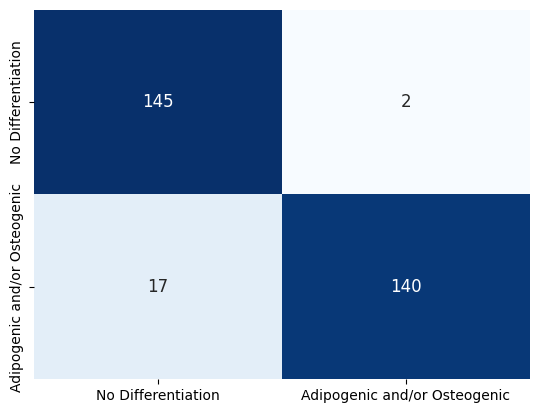

In [8]:
# labels for visual
class_names = ['No Differentiation', 'Adipogenic and/or Osteogenic']

# numeric confusion matrix
confusion_matrix = sklearn.metrics.confusion_matrix(true_numeric, pred)

# convert to df and make fancy confusion matrix
confusion_matrix_df = pd.DataFrame(confusion_matrix, index = class_names, columns = class_names)
sn.heatmap(confusion_matrix_df, annot=True, fmt='g', cbar=False, cmap='Blues', annot_kws={'fontsize' : 12})

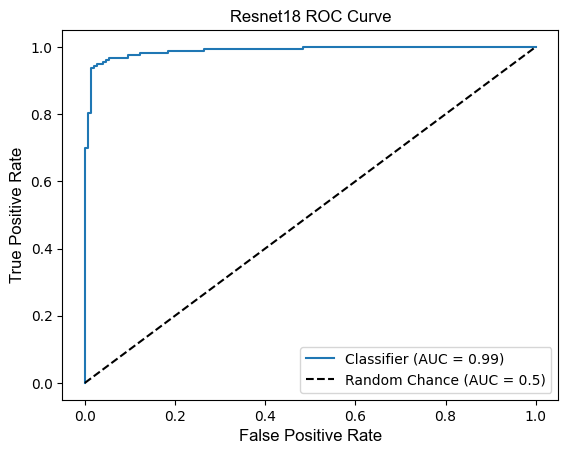

In [9]:
# roc curve
sklearn.metrics.RocCurveDisplay.from_predictions(true_numeric, np.array(pred_probs)[:,1])
plt.plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.5)")
plt.title('Resnet18 ROC Curve', fontname='Arial', fontsize=12)
plt.xlabel("False Positive Rate", fontname='Arial', fontsize=12)
plt.ylabel("True Positive Rate", fontname='Arial', fontsize=12)
plt.legend()

In [16]:
# computing metrics by class

all = []

for i in zip(true, pred, pred_probs):
    # basically flattening the true and pred class. i[0][0] is filename, i[0][1] is true class, i[1] is prediction
    all.append((i[0][0], i[0][1], i[1], i[2][1]))

# convert to dataframe for easy slicing
all_preds_and_labels = pd.DataFrame(all, columns=['File Group', 'True Class', 'Prediction', 'Pred Prob Positive'])

metrics_dict = dict()

# compute metrics for each filename
for i in set(all_preds_and_labels['File Group']):
    slice = all_preds_and_labels[all_preds_and_labels['File Group'] == i]
    metrics_dict['{} Accuracy'.format(i)] = sklearn.metrics.accuracy_score(np.array(slice['True Class']), np.array(slice['Prediction']))
    metrics_dict['{} Precision'.format(i)] = sklearn.metrics.precision_score(np.array(slice['True Class']), np.array(slice['Prediction']))
    metrics_dict['{} Recall'.format(i)] = sklearn.metrics.recall_score(np.array(slice['True Class']), np.array(slice['Prediction']))
    metrics_dict['{} F1'.format(i)] = sklearn.metrics.f1_score(np.array(slice['True Class']), np.array(slice['Prediction']))
    metrics_dict['{} AUC'.format(i)] = sklearn.metrics.roc_auc_score(np.array(slice['True Class']), np.array(slice['Pred Prob Positive']))

for i in metrics_dict.items():
    print(i)

('3day.4.15 Accuracy', 0.8)
('3day.4.15 Precision', 1.0)
('3day.4.15 Recall', 0.6)
('3day.4.15 F1', 0.7499999999999999)
('3day.4.15 AUC', 0.9824999999999999)
('2day.4.14 Accuracy', 0.9487179487179487)
('2day.4.14 Precision', 1.0)
('2day.4.14 Recall', 0.9)
('2day.4.14 F1', 0.9473684210526316)
('2day.4.14 AUC', 0.9921052631578947)
('3.6 Accuracy', 1.0)
('3.6 Precision', 1.0)
('3.6 Recall', 1.0)
('3.6 F1', 1.0)
('3.6 AUC', 1.0)
('ZOE_ALL Accuracy', 0.975)
('ZOE_ALL Precision', 1.0)
('ZOE_ALL Recall', 0.95)
('ZOE_ALL F1', 0.9743589743589743)
('ZOE_ALL AUC', 0.995)
('5day.4.17 Accuracy', 0.95)
('5day.4.17 Precision', 0.9090909090909091)
('5day.4.17 Recall', 1.0)
('5day.4.17 F1', 0.9523809523809523)
('5day.4.17 AUC', 0.9750000000000001)
('3.3 Accuracy', 0.9)
('3.3 Precision', 1.0)
('3.3 Recall', 0.85)
('3.3 F1', 0.9189189189189189)
('3.3 AUC', 1.0)
('2.28 Accuracy', 0.9473684210526315)
('2.28 Precision', 1.0)
('2.28 Recall', 0.8888888888888888)
('2.28 F1', 0.9411764705882353)
('2.28 AUC', 1.

In [17]:
true_train = []

# making predictions
for i in dataloaders['train']:
    true_train.extend(list(zip([j for j in i[0][0]], [int(j) for j in i[1]], [j for j in range(len(i[1]))])))
print(true_train)
all_train_labels = pd.DataFrame(true_train, columns=['File Group', 'True Class', 'ID'])

[('1day.4.13', 1, 0), ('2.28', 0, 1), ('2day.4.14', 1, 2), ('2.28', 1, 3), ('1day.4.13', 1, 4), ('3.3', 0, 5), ('3.6', 0, 6), ('3.6', 0, 7), ('3.3', 1, 8), ('3day.4.15', 0, 9), ('2day.4.14', 1, 10), ('3.6', 1, 11), ('3.3', 0, 12), ('2.28', 0, 13), ('3day.4.15', 0, 14), ('1day.4.13', 0, 15), ('5day.4.17', 1, 16), ('1day.4.13', 0, 17), ('3day.4.15', 0, 18), ('5day.4.17', 0, 19), ('3.6', 0, 20), ('3.3', 1, 21), ('5day.4.17', 0, 22), ('1day.4.13', 0, 23), ('2day.4.14', 0, 24), ('2.28', 1, 25), ('2.28', 0, 26), ('ZOE_ALL', 0, 27), ('2day.4.14', 0, 28), ('2.28', 1, 29), ('1day.4.13', 1, 30), ('3day.4.15', 1, 31), ('3day.4.15', 1, 32), ('ZOE_ALL', 0, 33), ('2.28', 0, 34), ('5day.4.17', 0, 35), ('3.3', 0, 36), ('1day.4.13', 0, 37), ('1day.4.13', 0, 38), ('1day.4.13', 0, 39), ('ZOE_ALL', 0, 40), ('ZOE_ALL', 0, 41), ('3day.4.15', 1, 42), ('ZOE_ALL', 1, 43), ('5day.4.17', 1, 44), ('3.3', 1, 45), ('2.28', 1, 46), ('1day.4.13', 1, 47), ('1day.4.13', 1, 48), ('3day.4.15', 1, 49), ('3.3', 0, 50), ('2

In [18]:
test_label_counts = all_preds_and_labels.groupby(['True Class', 'File Group']).count()
print(test_label_counts)

                       Prediction  Pred Prob Positive
True Class File Group                                
0          1day.4.13           19                  19
           2.28                20                  20
           2day.4.14           19                  19
           3.3                 10                  10
           3.6                 19                  19
           3day.4.15           20                  20
           5day.4.17           20                  20
           ZOE_ALL             20                  20
1          1day.4.13           19                  19
           2.28                18                  18
           2day.4.14           20                  20
           3.3                 20                  20
           3.6                 20                  20
           3day.4.15           20                  20
           5day.4.17           20                  20
           ZOE_ALL             20                  20


In [19]:
train_label_counts = all_train_labels.groupby(['True Class', 'File Group']).count()
print(train_label_counts)

                       ID
True Class File Group    
0          1day.4.13   62
           2.28        60
           2day.4.14   62
           3.3         30
           3.6         60
           3day.4.15   60
           5day.4.17   60
           ZOE_ALL     60
1          1day.4.13   62
           2.28        59
           2day.4.14   60
           3.3         60
           3.6         60
           3day.4.15   60
           5day.4.17   60
           ZOE_ALL     60
